## Step 1: Business Problem

The bank runs telephone campaigns to sell term deposits, but conversion is inconsistent. This analysis identifies which customer characteristics and campaign approaches are most associated with subscription, so marketing can priortize outreach and reduce wasted effort.

In [2]:
import pandas as pd 
df = pd.read_csv("bank.csv")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


## Step 2: Data Exploration

Dataset: 11,162 rows, 17 columns, no traditional nulls or duplicates.
Note: several columns use 'unknown' as a placeholder for missing data (joob, education, contact, poutcome) - treated as its own category rather than imputed.

In [3]:
df.shape

(11162, 17)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


In [5]:
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df['deposit'].value_counts(normalize=True)

deposit
no     0.52616
yes    0.47384
Name: proportion, dtype: float64

In [8]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


### Univariate Distributions

- Age: right-skewed, concentrated 25-45
- Balance: extreme right skew, median (550) far below mean (1,528) due to outliers
- Duration: righ-skewed, most calls short
- Target (deposit): near-balanced, 52.6% no / 47.4% yes

In [9]:
import  matplotlib.pyplot as plt
import seaborn as sns

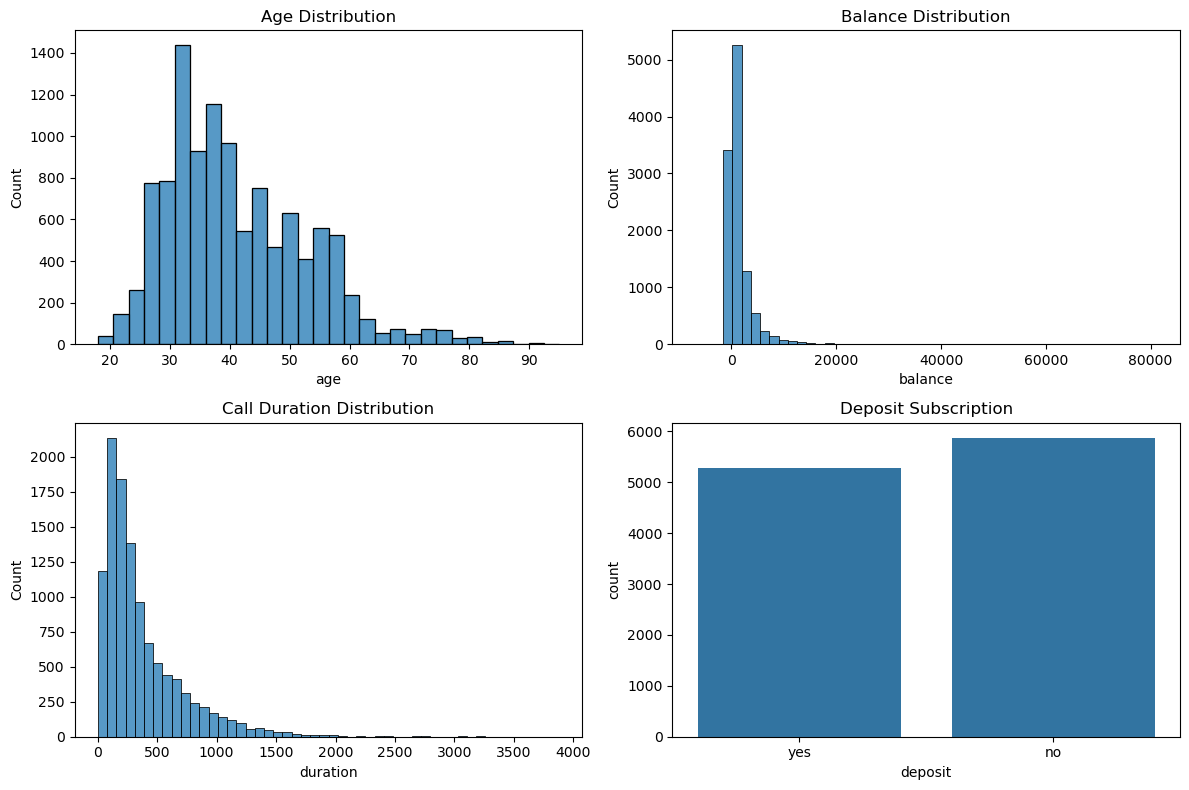

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12,8))
sns.histplot(df['age'], bins=30, ax=axes[0,0]).set_title('Age Distribution')
sns.histplot(df['balance'], bins=50, ax=axes[0,1]).set_title('Balance Distribution')
sns.histplot(df['duration'], bins=50, ax=axes[1,0]).set_title('Call Duration Distribution')
sns.countplot(x='deposit', data=df, ax=axes[1,1]).set_title('Deposit Subscription')
plt.tight_layout()
plt.savefig("visuals/univariate_distributions.png")
plt.show()

## Step 3: Key Drivers

Categorical analysis shows prvious campaign success, housing/personal loan status, job type and marital status are the strongest categorical drivers. Numeric correlation confirms call duration and (negatively) number of contact attempts as the strongest numeric signals.

In [11]:
categorical_cols = ['job', 'marital', 'education', 'housing', 'loan', 'poutcome', 'contact']

for col in categorical_cols:
    print(f"\n--- {col} vs deposit ---")
    print(df.groupby(col)['deposit'].value_counts(normalize=True).unstack())


--- job vs deposit ---
deposit              no       yes
job                              
admin.         0.526987  0.473013
blue-collar    0.635802  0.364198
entrepreneur   0.625000  0.375000
housemaid      0.602190  0.397810
management     0.492985  0.507015
retired        0.336761  0.663239
self-employed  0.538272  0.461728
services       0.600217  0.399783
student        0.252778  0.747222
technician     0.539221  0.460779
unemployed     0.434174  0.565826
unknown        0.514286  0.485714

--- marital vs deposit ---
deposit         no       yes
marital                     
divorced  0.518948  0.481052
married   0.566210  0.433790
single    0.456509  0.543491

--- education vs deposit ---
deposit          no       yes
education                    
primary    0.606000  0.394000
secondary  0.552593  0.447407
tertiary   0.458932  0.541068
unknown    0.492958  0.507042

--- housing vs deposit ---
deposit        no       yes
housing                    
no       0.429689  0.570311
yes  

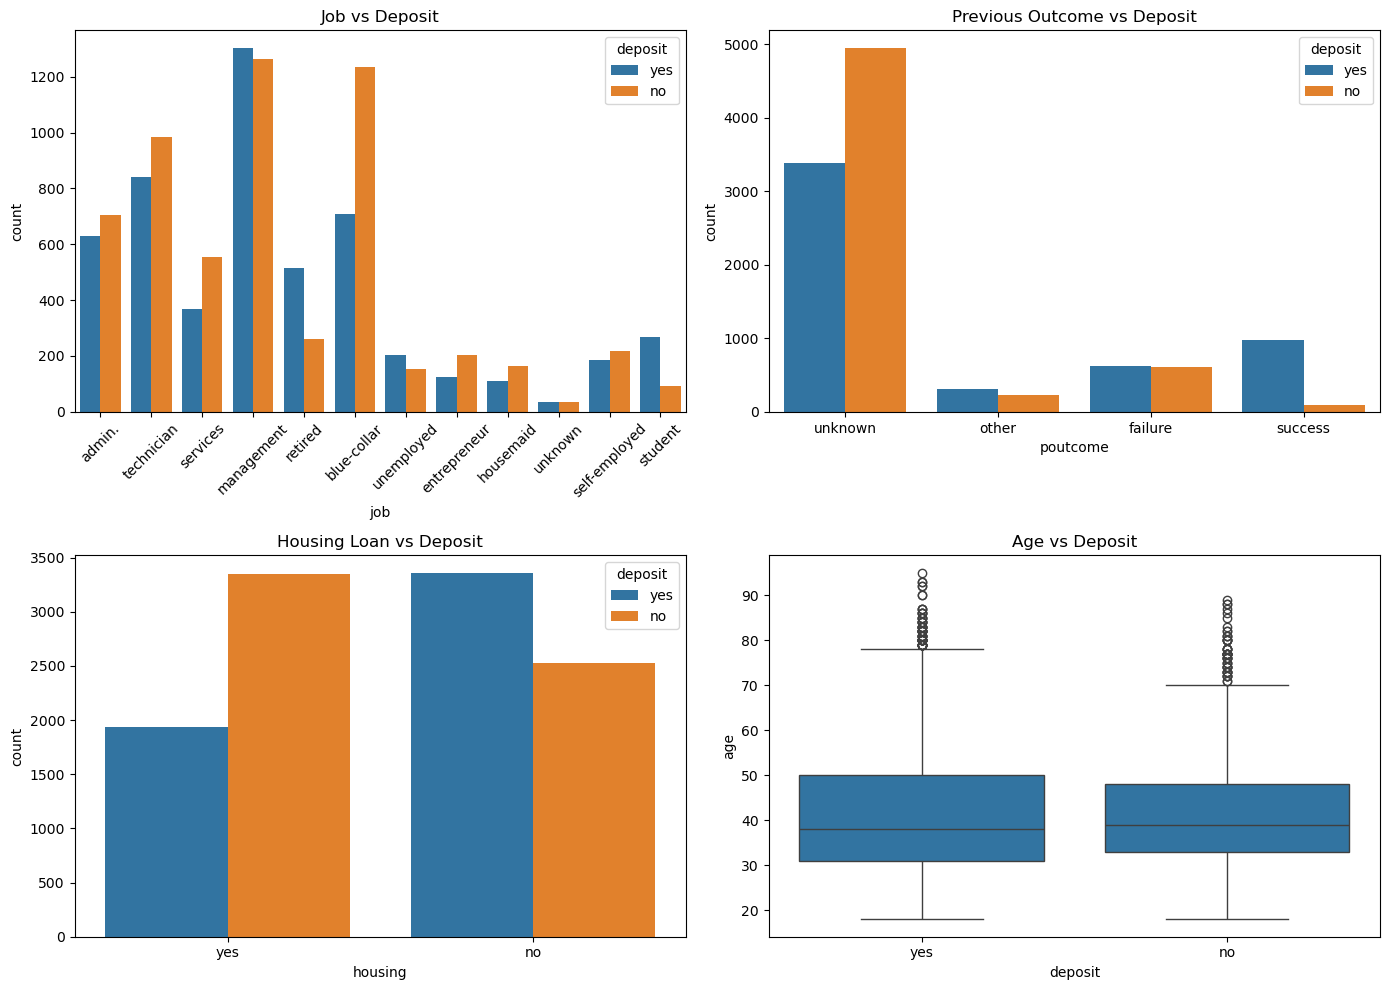

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=df, x='job', hue='deposit', ax=axes[0,0])
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].set_title('Job vs Deposit')

sns.countplot(data=df, x='poutcome', hue='deposit', ax=axes[0,1])
axes[0,1].set_title('Previous Outcome vs Deposit')

sns.countplot(data=df, x='housing', hue='deposit', ax=axes[1,0])
axes[1,0].set_title('Housing Loan vs Deposit')

sns.boxplot(data=df, x='deposit', y='age', ax=axes[1,1])
axes[1,1].set_title('Age vs Deposit')

plt.tight_layout()
plt.savefig("visuals/categorical_vs_deposit.png")
plt.show()

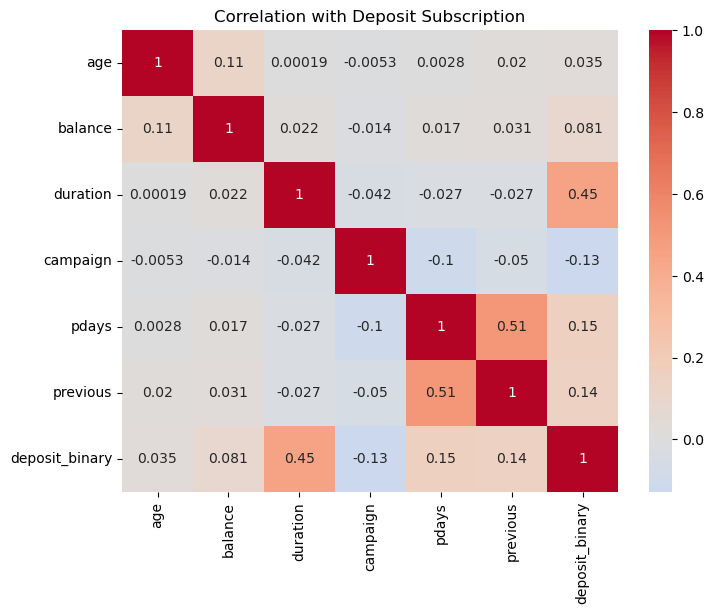

In [17]:
# Correlation heatmap for numeric features
plt.figure(figsize=(8,6))
numeric_df = df.copy()
numeric_df['deposit_binary'] = (df['deposit'] == 'yes').astype(int)
corr = numeric_df[['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'deposit_binary']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation with Deposit Subscription')
plt.savefig("correlation_heatmap.png")
plt.show()

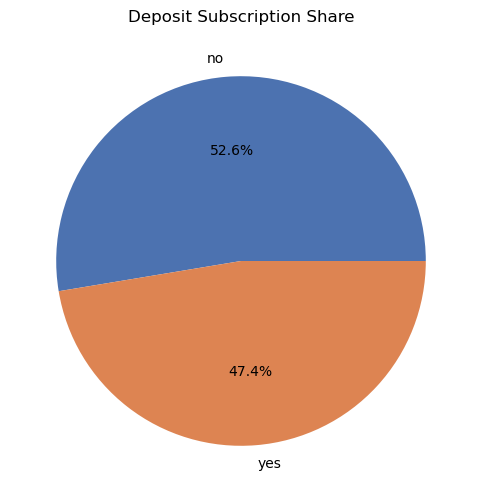

In [18]:
plt.figure(figsize=(6,6))
df['deposit'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#4C72B0', '#DD8452'])
plt.title('Deposit Subscription Share')
plt.ylabel('')
plt.savefig("deposit_pie_chart.png")
plt.show()

## Step 4: Business Insights

- Customers previously contacted with a successful outcome convert at over 90%, far above the ~47% baseline; prior relationship is the single strongest lever.
- Debt load matters; customers without a housing or personal loan convert noticeably more than those with either loans.
- Singles convert higher than married customers, plausibly linked to the same debt/liquidity pattern seen in the loan variables.
- Life-stage groups with more financial flexibility (students, retirees) convert well above average, while blue-collar and entrepreneur segments (likely carrying more financial obligations) convert below average.
- Married, blue-collar/entrepreneur customers with an existing housing or personal loan represent the lowest converting segment; worth deprioritizing or approaching differently rather than treating as equal-priority leads.
- Customers with poutcome= unknown (never contacted before) are the largest group but hardest to predict; this is where smarter targeting (using job, marital, loan status) matters most, since there's no prior-outcome signal to lean on.
- duration  is the strongest raw predictor but can't be used for pre-call targeting (only known after the call happens), and contact = unknown and poutcome = unknown likely reflect data collection gaps rather than real behavioural categories.
- Over-calling within a single campaign appears to erode conversion; a contact cap could improve efficiency without hurting the yes-rate.

## Step 5: Recommendations

- Prioritize marketing spend toward singles and customers without housing or personal loans, since these segments convert well above the ~47% baseline (54% and 57–67% respectively) while married and loan-holding customers convert notably lower, likely due to reduced financial flexibility.
- Since customers with a successful prior campaign outcome convert at over 90%, re-engagement of previously successful contacts should become a standing priority in future campaigns, rather than treating every campaign as starting from zero.
- Cap contact attempts per customer
  Since higher numbers of contact attempts within a campaign are associated with lower conversion (correlation of -0.13), marketing should cap outreach at 2–3 contacts per customer per campaign. Continuing to call unresponsive customers appears to erode goodwill rather than build it, reallocating that effort toward higher-probability segments would likely improve both conversion and campaign efficiency.
- Use profile-based targeting for first-time contacts
Since customers with no prior campaign history (poutcome = unknown) make up the largest share of the dataset and have no prior-outcome signal to rely on, marketing should prioritize this group using the demographic and financial signals that do predict conversion (job type, marital status, and loan status) rather than contacting them in an undifferentiated way. This turns the analysis's segment findings into a practical targeting rule for the hardest-to-predict group.


In [15]:
# Feature engineering for cleaner Power BI dashboarding
df_export = df.copy()
df_export['was_contacted_before'] = (df_export['pdays'] != -1).map({True: 'yes', False: 'no'})
df_export['deposit_binary'] = (df_export['deposit'] == 'yes').astype(int)

df_export.to_csv('bank_marketing_clean.csv', index=False)